In [1]:
import pandas as pd
import numpy as np
import os

from scipy.signal import savgol_filter
from sklearn.preprocessing import StandardScaler
from sklearn.cross_decomposition import PLSRegression
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error

# -----------------------------
# SNV transformation
# -----------------------------
def apply_snv(X):
    mean = np.mean(X, axis=1, keepdims=True)
    std = np.std(X, axis=1, keepdims=True)
    return (X - mean) / std

# -----------------------------
# Load data
# -----------------------------
train = pd.read_csv("../data/train.csv", encoding="cp932")
test  = pd.read_csv("../data/test.csv", encoding="cp932")

print("Train shape:", train.shape)
print("Test shape:", test.shape)

# -----------------------------
# Define spectral columns & trim edges
# -----------------------------
spectral_cols = [
    c for c in train.columns
    if c not in ["sample number", "species number", "樹種", "含水率"]
]

X = train[spectral_cols].values[:, 50:1500]  # trim noisy edges
X_test = test[spectral_cols].values[:, 50:1500]
y = train["含水率"].values

print("Number of spectral features after trimming:", X.shape[1])

# -----------------------------
# Preprocessing: SNV + SG 2nd derivative
# -----------------------------
print("Applying SNV transformation...")
X_snv = apply_snv(X)
X_test_snv = apply_snv(X_test)

print("Applying Savitzky-Golay second derivative...")
X_sg2 = savgol_filter(X_snv, window_length=21, polyorder=2, deriv=2, axis=1)
X_test_sg2 = savgol_filter(X_test_snv, window_length=21, polyorder=2, deriv=2, axis=1)

print("Preprocessing complete: SNV + SG 2nd derivative")

# -----------------------------
# Scale features
# -----------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_sg2)
X_test_scaled = scaler.transform(X_test_sg2)

# -----------------------------
# K-fold CV for PLS components
# -----------------------------
kf = KFold(n_splits=5, shuffle=True, random_state=42)
max_components = 20
cv_results = []

print("\nEvaluating PLS components using 5-fold CV...")

for n_comp in range(2, max_components+1):
    rmses = []
    for train_idx, val_idx in kf.split(X_scaled):
        X_train, X_val = X_scaled[train_idx], X_scaled[val_idx]
        y_train, y_val = y[train_idx], y[val_idx]

        pls = PLSRegression(n_components=n_comp)
        pls.fit(X_train, y_train)
        preds = pls.predict(X_val).flatten()

        rmse = np.sqrt(mean_squared_error(y_val, preds))
        rmses.append(rmse)

    mean_rmse = np.mean(rmses)
    cv_results.append((n_comp, mean_rmse))
    print(f"Components={n_comp:<2}  CV RMSE={mean_rmse:.4f}")

# Select best number of components
best_n_comp = min(cv_results, key=lambda x: x[1])[0]
print("\nBest number of components:", best_n_comp)

# -----------------------------
# Train final model on full data
# -----------------------------
pls_final = PLSRegression(n_components=best_n_comp)
pls_final.fit(X_scaled, y)
test_preds = pls_final.predict(X_test_scaled).flatten()

print("\nSample predictions:", test_preds[:10])

# -----------------------------
# Save submission
# -----------------------------
os.makedirs("../submissions", exist_ok=True)
submission = pd.DataFrame({
    "sample number": test["sample number"],
    "含水率": test_preds
})

output_path = f"../submissions/exp_nature_pls_cv_snv_sg2_{best_n_comp}comp_20260323.csv"
submission.to_csv(output_path, index=False, header=False)

print("\nSubmission saved:", output_path)
print(pd.read_csv(output_path, header=None).head())

Train shape: (1322, 1559)
Test shape: (550, 1558)
Number of spectral features after trimming: 1450
Applying SNV transformation...
Applying Savitzky-Golay second derivative...
Preprocessing complete: SNV + SG 2nd derivative

Evaluating PLS components using 5-fold CV...
Components=2   CV RMSE=20.1795
Components=3   CV RMSE=16.6299
Components=4   CV RMSE=15.0245
Components=5   CV RMSE=14.0198
Components=6   CV RMSE=13.5995
Components=7   CV RMSE=13.1623
Components=8   CV RMSE=12.9277
Components=9   CV RMSE=12.8140
Components=10  CV RMSE=12.5334
Components=11  CV RMSE=12.3450
Components=12  CV RMSE=12.2091
Components=13  CV RMSE=11.9157
Components=14  CV RMSE=11.7733
Components=15  CV RMSE=11.6616
Components=16  CV RMSE=11.5531
Components=17  CV RMSE=11.4625
Components=18  CV RMSE=11.2751
Components=19  CV RMSE=11.1253
Components=20  CV RMSE=11.0207

Best number of components: 20

Sample predictions: [165.27596497 165.23443867 165.4219712  150.85861063 139.26400608
 147.56555333 145.292543

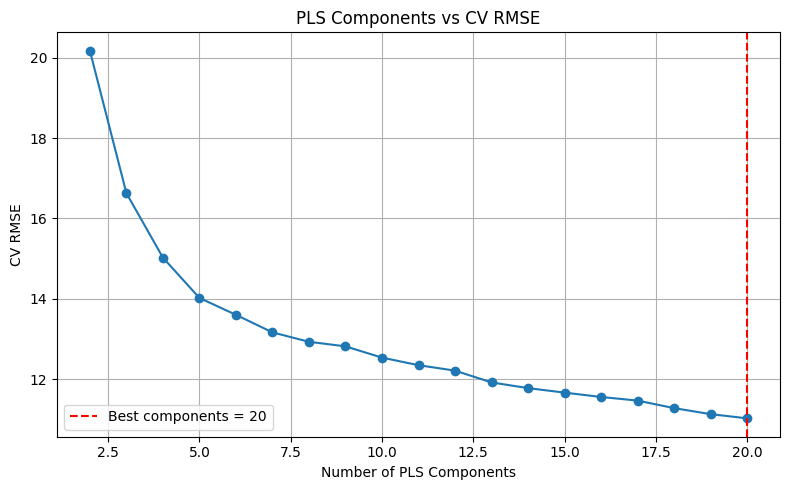

In [2]:
import matplotlib.pyplot as plt

# -----------------------------
# Plot RMSE vs PLS components
# -----------------------------
components, rmses = zip(*cv_results)

plt.figure(figsize=(8,5))
plt.plot(components, rmses, marker='o', linestyle='-')
plt.axvline(best_n_comp, color='r', linestyle='--', label=f'Best components = {best_n_comp}')
plt.title("PLS Components vs CV RMSE")
plt.xlabel("Number of PLS Components")
plt.ylabel("CV RMSE")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()